# House Prices — Feature Selection, Regularization & Model Building

This notebook continues directly from the EDA phase ([eda-ames-housing.ipynb](https://github.com/datawithumerz/ames-housing-capstone/blob/main/eda-ames-housing.ipynb)), where the Ames Housing dataset was cleaned, missing values treated, and key patterns and relationships explored. Building on that cleaned dataset, this notebook covers full preprocessing, rigorous feature selection, regression assumption diagnostics, and regularized model comparison — culminating in a final, defensible model for predicting `SalePrice`.

**Author:** Muhammad Umer Asad
[Kaggle](https://www.kaggle.com/datawithumerz) · [GitHub](https://github.com/datawithumerz) · [LinkedIn](https://www.linkedin.com/in/datawithumerz/)

---



### Recap from EDA

The EDA phase established:
- `SalePrice` was right-skewed (skew ≈ 1.88) and log-transformed (skew ≈ 0.12) to satisfy normality assumptions
- Extreme `GrLivArea` outliers were removed
- Top correlated predictors identified: `OverallQual` (0.82), `GrLivArea` (0.71), `GarageCars` (0.68), `TotalBsmtSF` (0.64)
- Multicollinearity flagged between `GarageArea`/`GarageCars` and `TotalBsmtSF`/`1stFlrSF`
- Output: `df_clean` — a cleaned, EDA-ready dataset saved to `data/processed/clean-ames-housing.csv`

This notebook picks up from that cleaned dataset.

### Dataset Overview

This notebook uses the same source data as the EDA phase — the Ames Housing dataset, comprising 1,460 rows and 79 explanatory features plus the target variable `SalePrice`, covering physical attributes, quality ratings, neighborhood, and sale conditions.

- **Source:** [Kaggle — House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)
- **Processed data:** [clean-ames-housing.csv](https://raw.githubusercontent.com/datawithumerz/ames-housing-capstone/refs/heads/main/data/processed/clean-ames-housing.csv)

### Table of Contents
1. [Setup & Data Loading](#1.-setup-&-data-loading)
   - 1a. Import Libraries
   - 1b. Load Cleaned Data
2. [Baseline Model](#2.-baseline-model)
   - 2a. Small Baseline (Top 4 Correlated Features) — OLS
   - 2b. Reading the OLS Summary
3. [Full Preprocessing Pipeline](#3.-full-preprocessing-pipeline)
   - 3a. Column Classification (Numeric / Ordinal / Nominal / Temporal)
   - 3b. ColumnTransformer — Scaling, Ordinal Encoding, One-Hot Encoding
   - 3c. Full-Feature Baseline (206 Features) — Linear Regression
   - 3d. R² vs Adjusted R² Gap — Motivation for Feature Selection
4. [Feature Selection](#4.-feature-selection)
   - 4a. Duplicate Feature Check
   - 4b. Filter — Correlation-Based Pruning (Feature-to-Feature)
   - 4c. Filter — SelectKBest (f_regression / ANOVA F-test)
   - 4d. Wrapper — Sequential Forward Selection
   - 4e. Embedded — Lasso / LassoCV
5. [Assumption Diagnostics](#5.-assumption-diagnostics)
   - 5a. Linearity
   - 5b. Independence of Errors (Durbin-Watson)
   - 5c. Homoscedasticity (Breusch-Pagan, Robust SEs)
   - 5d. Normality of Residuals
   - 5e. Multicollinearity (Condition Number, VIF)
   - 5f. Influential Observations (Cook's Distance)
6. [Final Model Selection](#6.-final-model-selection)
   - 6a. OLS vs Ridge vs Lasso vs ElasticNet Comparison
   - 6b. Final Model Decision
7. [Project Summary](#7.-project-summary)

## 1. Setup & Data Loading

This section imports the core libraries used throughout the notebook and loads the cleaned dataset that feeds into the baseline and full-feature models.

### 1a. Import Libraries

Core libraries for data handling, visualization, and statistical modeling are imported here, along with display and warning settings to keep notebook output clean and readable. Library-specific imports (e.g. `Lasso`, `het_breuschpagan`) are introduced later in the notebook, right where each is first used, rather than all bundled here — keeping each import visibly tied to the step that needs it.

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

### 1b. Load Cleaned Data

The cleaned Ames Housing dataset is loaded from the processed data directory. `keep_default_na=False` is used because several columns in this dataset use the string `"NA"` as a legitimate category value (e.g. "No Alley Access", "No Basement", "No Fireplace") rather than a missing value — pandas' default NA-handling would otherwise silently convert these valid categories into actual `NaN`, wrongly treating meaningful data as missing.

In [2]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/datawithumerz/ames-housing-capstone/refs/heads/main/data/processed/clean-ames-housing.csv",
    keep_default_na=False
)

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8.062258,8450,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NA,Attchd,2000-2010,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NA,NA,NA,0,2,2008,WD,Normal,12.247699
1,2,20,RL,8.944272,9600,Pave,NA,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1950-2000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NA,NA,NA,0,5,2007,WD,Normal,12.109016
2,3,60,RL,8.246211,11250,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2000-2010,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NA,NA,NA,0,9,2008,WD,Normal,12.317171
3,4,70,RL,7.745967,9550,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1950-2000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NA,NA,NA,0,2,2006,WD,Abnorml,11.849405
4,5,60,RL,9.165151,14260,Pave,NA,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000-2010,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NA,NA,NA,0,12,2008,WD,Normal,12.429220


## 2. Baseline Model

### 2a. Small Baseline (Top 4 Correlated Features) — OLS

A simple baseline model is built first using a small, manually chosen feature set — the top numeric predictors plus a few categorical features — before moving to the full preprocessing pipeline. This gives a reference point to compare later, more complex models against.

#### Encode categorical features

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
# Select the categorical columns for the baseline model
x_cat=df[['ExterQual','Neighborhood','KitchenQual']].copy()

In [5]:
x_cat['ExterQual'].unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [6]:
x_cat['Neighborhood'].unique()

array(['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',
       'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes',
       'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert',
       'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU',
       'Blueste'], dtype=object)

In [7]:
x_cat['KitchenQual'].unique()


array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [8]:
# ExterQual and KitchenQual are ordinal (quality has a natural order) -> ordinal encode
qual_order=['Fa','TA','Gd','Ex' ]
ord_encoder=OrdinalEncoder(categories=[qual_order,qual_order])
x_cat[['ExterQual_enc','KitchenQual_enc']]=ord_encoder.fit_transform(x_cat[['ExterQual','KitchenQual']])

In [9]:
# Neighborhood has no natural order -> one-hot encode instead
x_dummies=pd.get_dummies(x_cat['Neighborhood'],prefix='nbhd',drop_first=True,)

#### Assemble feature matrix and target

In [10]:
# Combine encoded categorical features with top correlated numeric features
x=pd.concat([
    x_cat[['ExterQual_enc','KitchenQual_enc']],
    df[['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF' ]],
    x_dummies],axis=1
)

In [11]:
x.head()

,ExterQual_enc,KitchenQual_enc,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,nbhd_Blueste,nbhd_BrDale,nbhd_BrkSide,nbhd_ClearCr,nbhd_CollgCr,nbhd_Crawfor,nbhd_Edwards,nbhd_Gilbert,nbhd_IDOTRR,nbhd_MeadowV,nbhd_Mitchel,nbhd_NAmes,nbhd_NPkVill,nbhd_NWAmes,nbhd_NoRidge,nbhd_NridgHt,nbhd_OldTown,nbhd_SWISU,nbhd_Sawyer,nbhd_SawyerW,nbhd_Somerst,nbhd_StoneBr,nbhd_Timber,nbhd_Veenker
0,2.0,2.0,7,1710,2,856,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1.0,1.0,6,1262,2,1262,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,2.0,2.0,7,1786,2,920,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,1.0,2.0,7,1717,3,756,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2.0,2.0,8,2198,3,1145,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [12]:
y=df['SalePrice'].copy()

#### Train/test split

In [13]:
from sklearn.preprocessing import StandardScaler

x_train_ols,x_test_ols,y_train_ols,y_test_ols=train_test_split(x,y,test_size=0.2,random_state=39)
# Reset indices after split to avoid misalignment issues later
x_train_ols=x_train_ols.reset_index(drop=True)
x_test_ols=x_test_ols.reset_index(drop=True)
y_train_ols=y_train_ols.reset_index(drop=True)
y_test_ols=y_test_ols.reset_index(drop=True)

#### Scale features

In [14]:
# Standardize features so OLS coefficients are comparable in magnitude
sds=StandardScaler()
x_train_ols=sds.fit_transform(x_train_ols)
x_test_ols=sds.transform(x_test_ols) # transform only, using train-fitted scaler, to avoid data leakage
x_train_ols=pd.DataFrame(x_train_ols,columns=x.columns)
x_test_ols=pd.DataFrame(x_test_ols,columns=x.columns)

This baseline intentionally uses raw multicollinear features to establish a reference point before the full preprocessing/selection pipeline addresses it downstream.

#### Fit baseline OLS model

In [15]:
# Add intercept term and fit the baseline OLS model
x_train_ols=sm.add_constant(x_train_ols)
model=sm.OLS(y_train_ols,x_train_ols).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     284.3
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:17:45   Log-Likelihood:                 676.68
No. Observations:                1163   AIC:                            -1291.
Df Residuals:                    1132   BIC:                            -1135.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              12.0332      0.004   29

### 2b. Reading the OLS Summary

The baseline OLS summary is reviewed to check overall fit (R², Adjusted R², F-statistic) and flag any red flags in the coefficient table before moving forward. In this case, the summary revealed a severe multicollinearity issue — condition number of 2.25e+15 and a near-zero coefficient on x1 — traced to a redundant or zero-variance column in the feature set. The model is then evaluated on the held-out test set to confirm performance generalizes.

In [16]:
from sklearn.metrics import r2_score

x_test_ols = sm.add_constant(x_test_ols, has_constant='add')
y_pred_ols = model.predict(sm.add_constant(x_test_ols))

r2=r2_score(y_test_ols,y_pred_ols)
print(f'R2 score on test set: {r2:.4f}')

adj_r2=1-(1-r2)*(len(y_test_ols)-1)/(len(y_test_ols)-x_test_ols.shape[1]-1)
print(f'Adjusted R2 score on test set: {adj_r2:.4f}')

R2 score on test set: 0.8097
Adjusted R2 score on test set: 0.7870


A test-set R² of 0.8097 and Adjusted R² of 0.7870 represent a meaningful drop from the training values (R²=0.883, Adj R²=0.880), indicating the baseline model does not generalize as well as the training fit suggested. This gap is consistent with overfitting, but given the severe multicollinearity identified in the OLS summary (condition number of 2.25e+15), the drop may also reflect unstable coefficient estimates rather than overfitting alone. This baseline result, combined with the multicollinearity issue, motivates the move to a more principled feature selection and preprocessing pipeline in the sections that follow.

## 3. Full Preprocessing Pipeline

### 3a. Column Classification (Numeric / Ordinal / Nominal / Temporal)

Before building the `ColumnTransformer`, columns are classified by type so each can be preprocessed appropriately — numeric features are scaled, ordinal features are encoded with an explicit rank order, and nominal (unordered categorical) features are one-hot encoded.

#### Check dtypes and fix MSSubClass

In [17]:
df.select_dtypes(include='object').columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='object')

In [18]:
df.select_dtypes(include='number').columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [19]:
df['MSSubClass']=df['MSSubClass'].astype('object')

#### Define feature groups by type and encoding strategy

In [20]:
# Numeric (continuous/count) features -> to be scaled
numeric_features=['LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond' , 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']

# Ordinal groups — each has an explicit rank order for OrdinalEncoder
ExtKitHeat_features=['ExterQual', 'KitchenQual','ExterCond','HeatingQC']
ExtKitHeat_qual=['Po','Fa', 'TA','Gd', 'Ex']

LotShape_feature=['LotShape']
LotShape_order=['Reg', 'IR1', 'IR2', 'IR3']

BsFpGarPol_features=['BsmtQual','FireplaceQu','GarageQual','PoolQC','BsmtCond','GarageCond']
BsFpGarPol_qual=['NA','Po','Fa', 'TA','Gd', 'Ex']

bsmt_exposure_fetaure=['BsmtExposure']
bsmt_exposure_order=['No', 'NA', 'Mn', 'Av', 'Gd']

bsmt_finish_features=[ 'BsmtFinType1','BsmtFinType2']
bsmt_finish_order=['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']

functional_feature=['Functional']
functional_order=['Sal','Sev','Maj2','Maj1', 'Mod','Min2','Min1','Typ']

grage_finish_feature=['GarageFinish']
grage_finish_order=['NA', 'Unf','RFn', 'Fin' ]

paveddrive_feature=['PavedDrive']
paveddrive_order=['N', 'P','Y']

fence_feature=['Fence']
fence_order=['NA', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']

utilities_feature=['Utilities']
utilities_order=['ELO','NoSeWa','NoSewr','AllPub' ]

landslope_feature=['LandSlope']
landslope_order=['Sev','Mod','Gtl' ]

# Temporal/binned feature — build year grouped into ranges, treated as ordinal
GarageYrBlt_feature=['GarageYrBlt']
GarageYrBlt_order= ['NA', '1900-1950', '1950-2000', '2000-2010', '2010-2025']


# Nominal (unordered categorical) features -> to be one-hot encoded
nominal_features=['Condition1', 'Condition2','BldgType','HouseStyle','MSZoning',
       'Street','Alley','LandContour','LotConfig', 'Neighborhood','RoofStyle',
       'RoofMatl','Exterior1st','Exterior2nd','MasVnrType','Foundation','Heating',
       'CentralAir', 'Electrical','MiscFeature','SaleType', 'SaleCondition','GarageType',
       'MSSubClass']

### 3b. ColumnTransformer — Scaling, Ordinal Encoding, One-Hot Encoding

A `ColumnTransformer` is built to apply the appropriate preprocessing to each feature group defined in the previous step: numeric features are standardized, each ordinal group is encoded with its explicit rank order and then scaled, and nominal features are one-hot encoded (dropping the first category to avoid the dummy variable trap, with unknown categories ignored at transform time for safety on unseen data).

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
preprocessor=ColumnTransformer([
    ('num',StandardScaler(),numeric_features),
    ('ExtKitHeat',Pipeline([
        ('encode',OrdinalEncoder(categories=[ExtKitHeat_qual]*len(ExtKitHeat_features))),
        ('scale', StandardScaler())]),
        ExtKitHeat_features),
    
    ('LotShape',Pipeline([
        ('encode',OrdinalEncoder(categories=[LotShape_order]*len(LotShape_feature))),
        ('scale',StandardScaler())]),
        LotShape_feature),
    
    ('BsFpGarPol',Pipeline([
        ('encode',OrdinalEncoder(categories=[BsFpGarPol_qual]*len(BsFpGarPol_features))),
        ('scale',StandardScaler())]),
        BsFpGarPol_features),
     
    ('bsmt_exposure',Pipeline([
        ('encode',OrdinalEncoder(categories=[bsmt_exposure_order]*len(bsmt_exposure_fetaure))),
        ('scale',StandardScaler())]),
        bsmt_exposure_fetaure),
    
    ('bsmt_finish',Pipeline([
            ('encode',OrdinalEncoder(categories=[bsmt_finish_order]*len(bsmt_finish_features))),
            ('scale',StandardScaler())]),
            bsmt_finish_features),
    
    ('functional',Pipeline([
                ('encode',OrdinalEncoder(categories=[functional_order]*len(functional_feature))),
                ('scale',StandardScaler())]),
                functional_feature),
    ('grage_finish',Pipeline([
                ('encode',OrdinalEncoder(categories=[grage_finish_order]*len(grage_finish_feature))),
                ('scale',StandardScaler())]),
                grage_finish_feature),
    
    ('paveddrive',Pipeline([
                ('encode',OrdinalEncoder(categories=[paveddrive_order]*len(paveddrive_feature))),
                ('scale',StandardScaler())]),
                paveddrive_feature),
       
    ('fence',Pipeline([
                ('encode',OrdinalEncoder(categories=[fence_order]*len(fence_feature))),
                ('scale',StandardScaler())]),
                fence_feature),
    
    ('utilities',Pipeline([
                ('encode',OrdinalEncoder(categories=[utilities_order]*len(utilities_feature))),
                ('scale',StandardScaler())]),
                utilities_feature),
    
    ('landslope',Pipeline([
                ('encode',OrdinalEncoder(categories=[landslope_order]*len(landslope_feature))),
                ('scale',StandardScaler())]),
                landslope_feature),
    
    ('GarageYrBlt',Pipeline([
                ('encode',OrdinalEncoder(categories=[GarageYrBlt_order]*len(GarageYrBlt_feature))),
                ('scale',StandardScaler())]),
                GarageYrBlt_feature),

    ('nom',OneHotEncoder(drop='first',handle_unknown='ignore'),nominal_features)
])

### 3c. Full-Feature Baseline (206 Features) — Linear Regression

The full `ColumnTransformer` preprocessing pipeline is combined with a plain `LinearRegression` model into a single `Pipeline`, then fit on all available features (206 after encoding) to establish a full-feature baseline for comparison against the later, feature-selected models.

#### Build the pipeline

In [22]:
from sklearn.linear_model import LinearRegression
pipe=Pipeline([
    ('preprocessing',preprocessor),
    ('model',LinearRegression())
])


#### Split data and fit

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
x=df.drop(columns=['SalePrice'])
y=df['SalePrice']
x_train_pipe,x_test_pipe,y_train_pipe,y_test_pipe=train_test_split(x,y,test_size=0.2,random_state=56)
pipe.fit(x_train_pipe,y_train_pipe)
y_pred=pipe.predict(x_test_pipe)

### 3d. R² vs Adjusted R² Gap — Motivation for Feature Selection

In [24]:
r2 = r2_score(y_test_pipe, y_pred)
print(f'The R2 Score of the Linear Model is {r2}')

n = x_test_pipe.shape[0]

# reuse the already-fitted preprocessor from the pipeline instead of refitting
x_train_transformed = pipe.named_steps['preprocessing'].transform(x_train_pipe)
x_test_transformed = pipe.named_steps['preprocessing'].transform(x_test_pipe)
transformed_columns = pipe.named_steps['preprocessing'].get_feature_names_out()
print(f'The number of features in the transformed dataset is {x_train_transformed.shape[1]}')

p = x_train_transformed.shape[1]
Adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print(f'The Adjusted R2 Score of the Linear Model is {Adj_r2}')

The R2 Score of the Linear Model is 0.9088240995701822
The number of features in the transformed dataset is 206
The Adjusted R2 Score of the Linear Model is 0.6852260580399147


With all 206 transformed features, the full model shows a striking gap: R²=0.9088 but Adjusted R²=0.6852 — a drop of over 22 points. This is the clearest evidence yet that the full feature set is overparameterized relative to the training sample size: R² keeps climbing as features are added (it never penalizes extra predictors), while Adjusted R² correctly discounts the model for the number of parameters relative to observations, revealing that a large share of those 206 features are adding little genuine explanatory power. This gap is the direct motivation for the feature selection methods in Section 4.

## 4. Feature Selection

With the full 206-feature model showing a large R²/Adjusted R² gap, this section applies filter, wrapper, and embedded feature selection methods to reduce the feature set to a smaller, more generalizable subset before refitting.

#### 1. Filter based Methods

In [25]:
x_train_pipe.shape

(1163, 80)

In [26]:
x_train_trnsf_df=pd.DataFrame(data=x_train_transformed,columns=transformed_columns,index=x_train_pipe.index)
x_test_trnsf_df=pd.DataFrame(data=x_test_transformed,columns=transformed_columns,index=x_test_pipe.index)

In [27]:
x_train_trnsf_df.head()

,num__LotFrontage,num__LotArea,num__OverallQual,num__OverallCond,num__MasVnrArea,num__BsmtFinSF1,num__BsmtFinSF2,num__BsmtUnfSF,num__TotalBsmtSF,num__1stFlrSF,num__2ndFlrSF,num__LowQualFinSF,num__GrLivArea,num__BsmtFullBath,num__BsmtHalfBath,num__FullBath,num__HalfBath,num__BedroomAbvGr,num__KitchenAbvGr,num__TotRmsAbvGrd,num__Fireplaces,num__GarageCars,num__GarageArea,num__WoodDeckSF,num__OpenPorchSF,num__EnclosedPorch,num__3SsnPorch,num__ScreenPorch,num__PoolArea,num__MiscVal,ExtKitHeat__ExterQual,ExtKitHeat__KitchenQual,ExtKitHeat__ExterCond,ExtKitHeat__HeatingQC,LotShape__LotShape,BsFpGarPol__BsmtQual,BsFpGarPol__FireplaceQu,BsFpGarPol__GarageQual,BsFpGarPol__PoolQC,BsFpGarPol__BsmtCond,BsFpGarPol__GarageCond,bsmt_exposure__BsmtExposure,bsmt_finish__BsmtFinType1,bsmt_finish__BsmtFinType2,functional__Functional,grage_finish__GarageFinish,paveddrive__PavedDrive,fence__Fence,utilities__Utilities,landslope__LandSlope,GarageYrBlt__GarageYrBlt,nom__Condition1_Feedr,nom__Condition1_Norm,nom__Condition1_PosA,nom__Condition1_PosN,nom__Condition1_RRAe,nom__Condition1_RRAn,nom__Condition1_RRNe,nom__Condition1_RRNn,nom__Condition2_Feedr,nom__Condition2_Norm,nom__Condition2_PosA,nom__Condition2_PosN,nom__Condition2_RRAe,nom__Condition2_RRAn,nom__Condition2_RRNn,nom__BldgType_2fmCon,nom__BldgType_Duplex,nom__BldgType_Twnhs,nom__BldgType_TwnhsE,nom__HouseStyle_1.5Unf,nom__HouseStyle_1Story,nom__HouseStyle_2.5Fin,nom__HouseStyle_2.5Unf,nom__HouseStyle_2Story,nom__HouseStyle_SFoyer,nom__HouseStyle_SLvl,nom__MSZoning_FV,nom__MSZoning_RH,nom__MSZoning_RL,nom__MSZoning_RM,nom__Street_Pave,nom__Alley_NA,nom__Alley_Pave,nom__LandContour_HLS,nom__LandContour_Low,nom__LandContour_Lvl,nom__LotConfig_CulDSac,nom__LotConfig_FR2,nom__LotConfig_FR3,nom__LotConfig_Inside,nom__Neighborhood_Blueste,nom__Neighborhood_BrDale,nom__Neighborhood_BrkSide,nom__Neighborhood_ClearCr,nom__Neighborhood_CollgCr,nom__Neighborhood_Crawfor,nom__Neighborhood_Edwards,nom__Neighborhood_Gilbert,nom__Neighborhood_IDOTRR,nom__Neighborhood_MeadowV,nom__Neighborhood_Mitchel,nom__Neighborhood_NAmes,nom__Neighborhood_NPkVill,nom__Neighborhood_NWAmes,nom__Neighborhood_NoRidge,nom__Neighborhood_NridgHt,nom__Neighborhood_OldTown,nom__Neighborhood_SWISU,nom__Neighborhood_Sawyer,nom__Neighborhood_SawyerW,nom__Neighborhood_Somerst,nom__Neighborhood_StoneBr,nom__Neighborhood_Timber,nom__Neighborhood_Veenker,nom__RoofStyle_Gable,nom__RoofStyle_Gambrel,nom__RoofStyle_Hip,nom__RoofStyle_Mansard,nom__RoofStyle_Shed,nom__RoofMatl_Membran,nom__RoofMatl_Metal,nom__RoofMatl_Roll,nom__RoofMatl_Tar&Grv,nom__RoofMatl_WdShake,nom__RoofMatl_WdShngl,nom__Exterior1st_AsphShn,nom__Exterior1st_BrkComm,nom__Exterior1st_BrkFace,nom__Exterior1st_CemntBd,nom__Exterior1st_HdBoard,nom__Exterior1st_ImStucc,nom__Exterior1st_MetalSd,nom__Exterior1st_Plywood,nom__Exterior1st_Stone,nom__Exterior1st_Stucco,nom__Exterior1st_VinylSd,nom__Exterior1st_Wd Sdng,nom__Exterior1st_WdShing,nom__Exterior2nd_AsphShn,nom__Exterior2nd_Brk Cmn,nom__Exterior2nd_BrkFace,nom__Exterior2nd_CmentBd,nom__Exterior2nd_HdBoard,nom__Exterior2nd_ImStucc,nom__Exterior2nd_MetalSd,nom__Exterior2nd_Other,nom__Exterior2nd_Plywood,nom__Exterior2nd_Stone,nom__Exterior2nd_Stucco,nom__Exterior2nd_VinylSd,nom__Exterior2nd_Wd Sdng,nom__Exterior2nd_Wd Shng,nom__MasVnrType_BrkFace,nom__MasVnrType_None,nom__MasVnrType_Stone,nom__Foundation_CBlock,nom__Foundation_PConc,nom__Foundation_Slab,nom__Foundation_Stone,nom__Foundation_Wood,nom__Heating_GasW,nom__Heating_Grav,nom__Heating_Wall,nom__CentralAir_Y,nom__Electrical_FuseF,nom__Electrical_FuseP,nom__Electrical_Mix,nom__Electrical_SBrkr,nom__MiscFeature_NA,nom__MiscFeature_Othr,nom__MiscFeature_Shed,nom__MiscFeature_TenC,nom__SaleType_CWD,nom__SaleType_Con,nom__SaleType_ConLD,nom__SaleType_ConLI,nom__SaleType_ConLw,nom__SaleType_New,nom__SaleType_Oth,nom__SaleType_WD,nom__SaleCondition_AdjLand,nom__SaleCondition_Alloca,nom__SaleCondition_Family,nom__SaleCondition_Normal,nom__SaleCondition_Partial,nom__Gar

### 4a. Duplicate Feature Check

Transposing the training DataFrame and checking .duplicated() identifies columns that are exact duplicates of one another (a common byproduct of one-hot encoding sparse categories). One duplicate column, nom__MSSubClass_90, was found and dropped from both the train and test sets to avoid redundant, perfectly collinear features going into the next selection steps.

In [28]:
x_train_trnsf_df.T.duplicated().value_counts()


False    205
True       1
Name: count, dtype: int64

In [29]:
x_train_trnsf_df.columns[x_train_trnsf_df.T.duplicated(keep=False)]

Index(['nom__BldgType_Duplex', 'nom__MSSubClass_90'], dtype='object')

In [30]:
x_train_trnsf_df=x_train_trnsf_df.drop(columns=['nom__MSSubClass_90'])
x_test_trnsf_df=x_test_trnsf_df.drop(columns=['nom__MSSubClass_90'])
print(x_train_trnsf_df.shape)
print(x_test_trnsf_df.shape)

(1163, 205)
(291, 205)


The duplicate check found one pair of identical columns — `nom__BldgType_Duplex` and `nom__MSSubClass_90` — meaning these two one-hot encoded features carry perfectly redundant information. One of the pair (`nom__MSSubClass_90`) was dropped, reducing the feature count from 206 to 205 in both train and test sets.

### 4b. Filter — Variance Threshold

A `VarianceThreshold` filter was tested across several threshold values to see how many features survive at each cutoff, as a way of removing near-constant, low-information features.


In [31]:
from sklearn.feature_selection import VarianceThreshold
for t in [0.01, 0.002, 0.001,  0.00085911,0.00085910 ]:
    Vt=VarianceThreshold(threshold=t)
    Vt.fit(x_train_trnsf_df)
    
    print(f'Threshold:{t} -> {sum(Vt.get_support())} features Survive')

Threshold:0.01 -> 149 features Survive
Threshold:0.002 -> 180 features Survive
Threshold:0.001 -> 190 features Survive
Threshold:0.00085911 -> 190 features Survive
Threshold:0.0008591 -> 205 features Survive


**Finding:** changing the threshold by 0.00000001 (0.00085910 → 
0.00085911) caused 16 features to drop simultaneously. This extreme 
sensitivity shows a large cluster of features sits at nearly identical 
variance values — there is no stable, principled cutoff point to 
choose here.

**Reasoning:** our numeric and ordinal features are already 
StandardScaled (mean=0, variance≈1), which makes variance an 
unreliable signal of feature usefulness at this stage — nearly all 
scaled columns show similar variance regardless of their actual 
predictive value. A threshold aggressive enough to catch genuinely 
low-information one-hot columns also risks discarding rare-but-meaningful 
categories (e.g., SaleCondition_Partial, which Lasso later identifies 
as informative).

**Decision:** Variance Threshold is skipped. We proceed directly to 
correlation-based filtering and embedded methods (Lasso), which 
evaluate feature relevance relative to the target rather than in 
isolation.

### 4c. Filter — Correlation-Based Pruning (Feature-to-Feature)

Feature-to-feature correlation was computed on the training data (post-preprocessing) to detect redundant feature pairs — two features that carry largely the same information.

In [32]:
corr_matrix = x_train_pipe[numeric_features].corr().abs()
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_triangle=corr_matrix.where(mask)

In [33]:
high_corr_pairs=[(col , row, upper_triangle.loc[col,row])
                 for col in upper_triangle.columns
                 for row in upper_triangle.index
                 if pd.notna(upper_triangle.loc[col,row]) and upper_triangle.loc[col,row]>0.8 ]

In [34]:
high_corr_pairs

[('GrLivArea', 'TotRmsAbvGrd', np.float64(0.8346179206262369)),
 ('GarageCars', 'GarageArea', np.float64(0.8870960833744548))]

In [35]:
print(f'The correlation between "GrLivArea" and "SalePrice" is:' ,x_train_pipe['GrLivArea'].corr(y_train_pipe))
print(f'The correlation between "TotRmsAbvGrd" and "SalePrice" is:', x_train_pipe['TotRmsAbvGrd'].corr(y_train_pipe))
print(f'The correlation between "GarageCars" and "SalePrice" is:', x_train_pipe['GarageCars'].corr(y_train_pipe))
print(f'The correlation between "GarageArea" and "SalePrice" is:', x_train_pipe['GarageArea'].corr(y_train_pipe))



The correlation between "GrLivArea" and "SalePrice" is: 0.7137533163385618
The correlation between "TotRmsAbvGrd" and "SalePrice" is: 0.5255102957382185
The correlation between "GarageCars" and "SalePrice" is: 0.6815334110312272
The correlation between "GarageArea" and "SalePrice" is: 0.6561596677033544


In [36]:
x_train_trnsf_df =x_train_trnsf_df.drop(columns=['num__TotRmsAbvGrd','num__GarageArea'])
x_test_trnsf_df =x_test_trnsf_df.drop(columns=['num__TotRmsAbvGrd','num__GarageArea'])

In [37]:
print(f'The new shape of our dataframe is :{x_train_trnsf_df.shape}')
print(f'The new shape of our dataframe is :{x_test_trnsf_df.shape}')

The new shape of our dataframe is :(1163, 203)
The new shape of our dataframe is :(291, 203)


Feature-to-feature correlation was computed on the training data 
(post-preprocessing) to detect redundant feature pairs — two features 
that carry largely the same information.

Two highly correlated pairs were found (threshold: |r| > 0.8):

| Pair | Correlation | Kept | Dropped | Reason |
|---|---|---|---|---|
| GrLivArea / TotRmsAbvGrd | 0.835 | GrLivArea | TotRmsAbvGrd | GrLivArea has stronger correlation with SalePrice (0.714 vs 0.526) |
| GarageCars / GarageArea | 0.887 | GarageCars | GarageArea | GarageCars has stronger correlation with SalePrice (0.682 vs 0.656) |

**Decision rule:** for each highly correlated pair, retain the feature 
with the stronger correlation to the target, drop the other.

`TotRmsAbvGrd` and `GarageArea` were dropped directly from the 
transformed feature set, consistent with how duplicate features were 
handled in the previous step.

**Result:** feature count reduced from 205 → 203 columns 
(train: (1163, 203), test: (291, 203)).

### 4d. Filter — Feature-to-Target Correlation

Each feature's individual correlation with the target (`SalePrice`) was checked to assess raw predictive relevance.

In [38]:
target_corr = x_train_trnsf_df.corrwith(y_train_pipe).abs().sort_values(ascending=False)
target_corr_df=target_corr.reset_index()
target_corr_df.columns=['Feature','Corr with target']
target_corr_df.head()

,Feature,Corr with target
0,num__OverallQual,0.810732
1,num__GrLivArea,0.713753
2,num__GarageCars,0.681533
3,ExtKitHeat__ExterQual,0.676822
4,ExtKitHeat__KitchenQual,0.666951


In [39]:
target_corr_df.tail()

,Feature,Corr with target
198,nom__GarageType_Basment,0.004473
199,nom__LandContour_Lvl,0.003697
200,nom__MSSubClass_80,0.003231
201,nom__MSSubClass_75,0.002340
202,nom__SaleCondition_Alloca,0.001536


In [40]:
target_corr_df[target_corr_df['Corr with target']>0.01].count()
        

Feature             192
Corr with target    192
dtype: int64

(array([96., 41., 15., 20., 14.,  4.,  3.,  5.,  4.,  1.]),
 array([0.00153647, 0.08245604, 0.16337561, 0.24429518, 0.32521474,
        0.40613431, 0.48705388, 0.56797345, 0.64889301, 0.72981258,
        0.81073215]),
 <BarContainer object of 10 artists>)

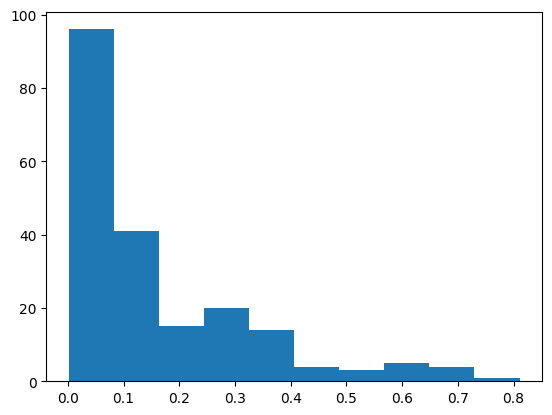

In [41]:
plt.hist(target_corr_df['Corr with target'])




Feature-to-target:Each feature's individual correlation with the target (`SalePrice`) was 
checked to assess raw predictive relevance:


**Finding:** the distribution is steady and skewed — most features 
cluster near zero correlation, with a long downward tail rather than a 
sharp natural cutoff point. Roughly 100 features show |r| > 0.02, while 
48 show |r| < 0.01.

**Limitation acknowledged:** raw correlation is a weak signal for 
individually assessing one-hot encoded columns — a single dummy (e.g. 
one specific Neighborhood category) will naturally show low correlation 
with the target even if the underlying categorical variable as a whole 
carries real signal. Manually picking a hard correlation threshold here 
would be arbitrary and could unfairly penalize categorical features.

**Decision:** rather than manually threshold this correlation value, it 
is used only as a rough sanity check to inform `k` in the more rigorous 
`SelectKBest(score_func=f_regression, k=100)` step next — `f_regression` 
properly evaluates each feature's statistical relationship to a 
continuous target and is better suited to finalizing this cut than 
manual correlation inspection alone.

### 4e. Filter — SelectKBest (f_regression / ANOVA F-test)

Rather than manually guessing a `k` value, `f_regression` was used to compute an F-statistic and p-value for every feature's relationship with `SalePrice`.

In [42]:
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import SelectKBest
sel=SelectKBest(f_regression,k=100).fit(x_train_trnsf_df,y_train_pipe)
selected_features=x_train_trnsf_df.columns[sel.get_support()]

In [43]:
x_train_trnsf_df[selected_features].shape

(1163, 100)

In [44]:
scores_df=pd.DataFrame(
    data={
        'Selected_Features':x_train_trnsf_df.columns,
        'f_score':sel.scores_,
        'p_values':sel.pvalues_
    }
).sort_values(by='f_score',ascending=False)

In [45]:
scores_df.tail(20)

,Selected_Features,f_score,p_values
120,nom__RoofMatl_Roll,0.253231,0.614905
46,utilities__Utilities,0.243822,0.621552
14,num__BsmtHalfBath,0.243806,0.621564
79,nom__Street_Pave,0.170786,0.679491
121,nom__RoofMatl_Tar&Grv,0.157730,0.691328
81,nom__Alley_Pave,0.148456,0.700086
116,nom__RoofStyle_Mansard,0.128331,0.720234
61,nom__Condition2_RRAe,0.118170,0.731090
195,nom__MSSubClass_70,0.117978,0.731300
70,nom__HouseStyle_2.5Fin,0.105042,0.745920


In [46]:
scores_df[scores_df['p_values']<0.05].count()

Selected_Features    133
f_score              133
p_values             133
dtype: int64

In [47]:
significant_features=scores_df[scores_df['p_values']<0.05]['Selected_Features']
x_train_trnsf_df=x_train_trnsf_df.loc[:,significant_features]
x_test_trnsf_df=x_test_trnsf_df.loc[:,significant_features]
print(x_train_trnsf_df.shape)
print(x_test_trnsf_df.shape)

(1163, 133)
(291, 133)


**Finding:** 133 of 203 features showed a statistically significant 
relationship with the target (p < 0.05) — more than the ~100 initially 
estimated from the rougher correlation-distribution check, since 
`f_regression` properly accounts for one-hot/ordinal columns that raw 
correlation undervalues.

**Decision:** used the actual significance threshold (p < 0.05) rather 
than an arbitrary `k`, keeping exactly the 133 features that pass this 
standard statistical bar.

**Result:** feature count reduced from 203 → 133 columns 
(train: (1163, 133), test: (291, 133)).

### 4f. Wrapper — Sequential Forward Selection

Sequential Forward Selection (SFS) was chosen over Backward Selection 
and Exhaustive Search: Backward would require many iterations to strip 
down from 133 features, and Exhaustive Search is computationally 
infeasible at this feature count. Forward Selection starts from zero 
and builds up, making it faster when the target feature count (50) is 
much smaller than the starting count (133).

Applied on the 133 features surviving the Filter phase, using 
`LinearRegression` as the estimator, 5-fold cross-validated R² as the 
scoring metric, targeting 50 final features.

##### Sequential Forward Selection:

In [48]:
from sklearn.feature_selection import SequentialFeatureSelector
sfs=SequentialFeatureSelector(estimator=LinearRegression(),
    n_features_to_select=50,direction='forward',scoring='r2',cv=5,
    n_jobs=-1)
sfs.fit(x_train_trnsf_df,y_train_pipe)
selected_mask=sfs.get_support()
selected_features_sfs=x_train_trnsf_df.columns[selected_mask]
print(selected_features_sfs.tolist())

['num__OverallQual', 'num__GrLivArea', 'num__GarageCars', 'ExtKitHeat__KitchenQual', 'num__TotalBsmtSF', 'GarageYrBlt__GarageYrBlt', 'BsFpGarPol__FireplaceQu', 'nom__Foundation_PConc', 'ExtKitHeat__HeatingQC', 'nom__MSZoning_RM', 'nom__Neighborhood_NridgHt', 'nom__MSSubClass_30', 'num__LotFrontage', 'num__BsmtFinSF1', 'num__WoodDeckSF', 'nom__SaleType_New', 'nom__CentralAir_Y', 'bsmt_finish__BsmtFinType1', 'bsmt_exposure__BsmtExposure', 'num__HalfBath', 'nom__MasVnrType_Stone', 'num__LotArea', 'nom__Neighborhood_NoRidge', 'nom__Exterior2nd_Wd Sdng', 'nom__Exterior1st_Wd Sdng', 'nom__Neighborhood_Edwards', 'nom__MSSubClass_50', 'functional__Functional', 'nom__Neighborhood_MeadowV', 'nom__Neighborhood_BrkSide', 'num__KitchenAbvGr', 'nom__Neighborhood_StoneBr', 'nom__Electrical_FuseF', 'nom__LotConfig_CulDSac', 'num__ScreenPorch', 'nom__MSZoning_FV', 'nom__MSSubClass_160', 'nom__MSSubClass_190', 'nom__HouseStyle_1.5Unf', 'nom__Condition1_Feedr', 'nom__Condition1_Norm', 'nom__Exterior1st_H

In [49]:
x_train_fs=x_train_trnsf_df.loc[:,selected_features_sfs]
x_test_fs=x_test_trnsf_df.loc[:,selected_features_sfs]
y_train_fs=y_train_pipe.copy()
y_test_fs=y_test_pipe.copy()
print(x_train_fs.shape)
print(x_test_fs.shape)

(1163, 50)
(291, 50)


**Result:** feature count reduced from 133 → 50 columns.

**Finding:** the selected 50 features are led by the same core drivers 
identified consistently across every prior method (OLS, correlation, 
earlier Lasso run) — `OverallQual`, `GrLivArea`, `GarageCars`, 
`KitchenQual`, and `TotalBsmtSF` — reinforcing confidence that these 
are genuinely the strongest predictors, independent of which selection 
method is used. The remaining 45 features are a mix of quality ratings, 
key neighborhood dummies (e.g. `NridgHt`, `NoRidge`, `StoneBr` — 
Ames' higher-end neighborhoods), and specific sale/construction 
characteristics (`SaleType_New`, `Foundation_PConc`, `CentralAir_Y`).

### 4g. Embedded — Lasso / LassoCV

`LassoCV` identified alpha=0.0003129 as the cross-validation-optimal 
value, retaining all 50 features (minimal shrinkage at this low 
penalty strength — consistent with Wrapper/SFS having already removed 
most weak features beforehand).

To explore the tradeoff between model complexity and performance, alpha 
was manually swept across a range:

##### Lasso Regularization

In [50]:
from sklearn.linear_model import  Lasso,LassoCV
lasso_cv=LassoCV(cv=5,random_state=42,max_iter=5000)
lasso_cv.fit(x_train_fs,y_train_fs)
best_alpha=lasso_cv.alpha_
print(f'The best alpha is:{best_alpha}')

The best alpha is:0.0003129372582654218


In [51]:
for i in [best_alpha,0.001,0.003,0.005, 0.007, 0.01, 0.03 , 0.05]:
    lasso_manual=Lasso(alpha=i,max_iter=5000)
    lasso_manual.fit(x_train_fs,y_train_fs)
    lasso_manual_y_pred=lasso_manual.predict(x_test_fs)
    lasso_manual_r2=r2_score(y_test_fs,lasso_manual_y_pred)
    n_drops=sum(lasso_manual.coef_==0)
    lasso_manual_adj_r2=1-(1-lasso_manual_r2)*(len(y_test_fs)-1)/(len(y_test_fs)-(x_train_fs.shape[1]-n_drops)-1)
    print(f"Features surviving Lasso for alpha:{i}: {(x_train_fs.shape[1]-n_drops)} out of 50")
    print(f'The R2 score of the Lasso model for alpha:{i} is: {lasso_manual_r2:.4f}')    
    print(f'The Adjusted R2 score of the Lasso model for alpha:{i} is: {lasso_manual_adj_r2:.4f}')
    print()



Features surviving Lasso for alpha:0.0003129372582654218: 50 out of 50
The R2 score of the Lasso model for alpha:0.0003129372582654218 is: 0.8953
The Adjusted R2 score of the Lasso model for alpha:0.0003129372582654218 is: 0.8735

Features surviving Lasso for alpha:0.001: 37 out of 50
The R2 score of the Lasso model for alpha:0.001 is: 0.8935
The Adjusted R2 score of the Lasso model for alpha:0.001 is: 0.8779

Features surviving Lasso for alpha:0.003: 29 out of 50
The R2 score of the Lasso model for alpha:0.003 is: 0.8813
The Adjusted R2 score of the Lasso model for alpha:0.003 is: 0.8681

Features surviving Lasso for alpha:0.005: 22 out of 50
The R2 score of the Lasso model for alpha:0.005 is: 0.8719
The Adjusted R2 score of the Lasso model for alpha:0.005 is: 0.8614

Features surviving Lasso for alpha:0.007: 21 out of 50
The R2 score of the Lasso model for alpha:0.007 is: 0.8709
The Adjusted R2 score of the Lasso model for alpha:0.007 is: 0.8608

Features surviving Lasso for alpha:0.

| Alpha | Features | R² | Adj R² |
|---|---|---|---|
| 0.001 | 37 | 0.8935 | 0.8779 |
| 0.0003129 (CV-optimal) | 50 | 0.8953 | 0.8735 |
| 0.003 | 29 | 0.8813 | 0.8681 |
| **0.005** | **22** | **0.8719** | **0.8614** |
| 0.007 | 21 | 0.8709 | 0.8608 |
| 0.01 | 20 | 0.8689 | 0.8592 |
| 0.03 | 15 | 0.8473 | 0.8390 |
| 0.05 | 10 | 0.8121 | 0.8054 |

**Decision:** alpha=0.005 (22 features) was selected over the strictly 
higher-scoring alpha=0.001 (37 features, Adj R²=0.8779). This trades 
~1.65 points of Adjusted R² for a substantially leaner, more 
interpretable final model — fewer than half the features of the 
CV-optimal choice, easier to validate assumptions on (lower risk of 
multicollinearity, cleaner VIF check) and easier to communicate in a 
write-up. This is a deliberate parsimony-over-marginal-fit tradeoff, 
not an oversight.

In [52]:
final_lasso=Lasso(alpha=0.005,max_iter=5000)
final_lasso.fit(x_train_fs,y_train_fs)
y_pred_lasso=final_lasso.predict(x_test_fs)
n_drops=sum(final_lasso.coef_==0)
r2_lasso=r2_score(y_test_fs,y_pred_lasso)
adj_r2_lasso=1-(1-r2_lasso)*(len(y_test_fs)-1)/(len(y_test_fs)-(x_train_fs.shape[1]-n_drops)-1)
print(f'The R2 score of the Lasso model is: {r2_lasso:.4f}')
print(f'The Adjusted R2 score of the Lasso model is: {adj_r2_lasso:.4f}')
survived_features=x_train_fs.columns[final_lasso.coef_!=0]
print(f'The Number of features surviving Lasso is: {len(survived_features)} out of 50')

The R2 score of the Lasso model is: 0.8719
The Adjusted R2 score of the Lasso model is: 0.8614
The Number of features surviving Lasso is: 22 out of 50


In [53]:
x_train_fs=x_train_fs[survived_features]
x_test_fs=x_test_fs[survived_features]
print(f'The new shape of the training set is: {x_train_fs.shape}')
print(f'The new shape of the test set is: {x_test_fs.shape}')

The new shape of the training set is: (1163, 22)
The new shape of the test set is: (291, 22)


## 5. Assumption Diagnostics

### 5a. Linearity

Linearity was assessed using residual-vs-predicted plots for both the training and test sets.

#### i) Fit OLS Model

In [54]:
import statsmodels.api as sm

x_train_final_sm = sm.add_constant(x_train_fs)
ols_model = sm.OLS(y_train_fs, x_train_final_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     455.4
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:21:47   Log-Likelihood:                 783.38
No. Observations:                1163   AIC:                            -1521.
Df Residuals:                    1140   BIC:                            -1404.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

An OLS model was fit using statsmodels on the final selected feature set, with a constant (intercept) term added. The .summary() output provides the coefficients, standard errors, R²/Adjusted R², and the diagnostic statistics (Omnibus, Durbin-Watson, condition number, etc.) needed for the assumption checks that follow.

#### ii) Residual Plot (Train and Test)

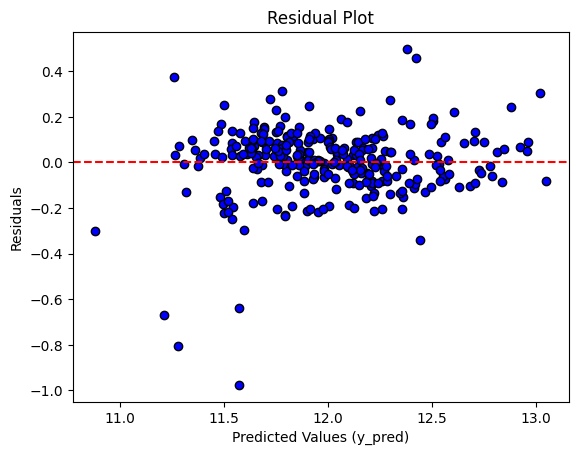

In [55]:
x_test_final_sm = sm.add_constant(x_test_fs)

y_pred_ols = ols_model.predict(x_test_final_sm)

residuals = y_test_fs - y_pred_ols

plt.scatter(y_pred_ols, residuals, color='blue', edgecolor='k')

plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

plt.xlabel('Predicted Values (y_pred)')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

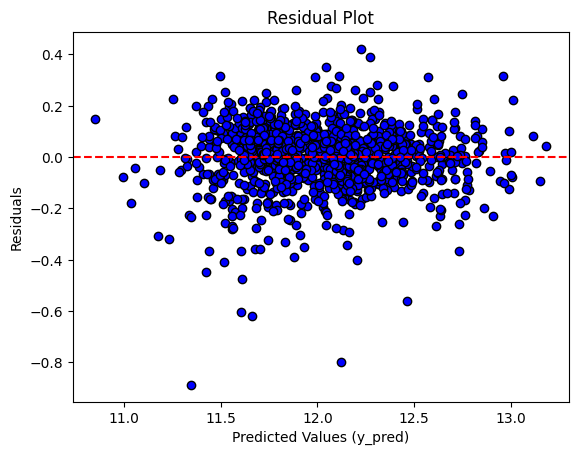

In [56]:
y_train_pred_ols = ols_model.predict(x_train_final_sm)

residuals = y_train_fs - y_train_pred_ols

plt.scatter(y_train_pred_ols, residuals, color='blue', edgecolor='k')

plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

plt.xlabel('Predicted Values (y_pred)')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

Residuals were plotted against predicted values for both the training and test sets to check for linearity (no systematic pattern) and homoscedasticity (constant variance across the range of predictions). Comparing train and test side by side also helps confirm the model isn't overfitting — if the test residual spread is noticeably worse than train, that's a sign of poor generalization.

**Finding:** in both plots, residuals were scattered randomly around zero with no clear curvature or systematic pattern. This suggests the relationship between predictors and target is adequately captured by a linear model, so the linearity assumption appears to hold.

### 5b. Independence of Errors (Durbin-Watson)

Independence of errors was assessed using the Durbin-Watson statistic reported in the OLS summary.

**Finding:** the statistic was approximately 1.974, very close to the ideal value of 2.0, indicating little to no evidence of meaningful autocorrelation among the residuals. The independence assumption appears to hold.

### 5c. Homoscedasticity (Breusch-Pagan, Robust SEs)

Homoscedasticity was initially assessed visually using the residual-vs-predicted plots, then tested formally with the Breusch-Pagan test.

In [57]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import OLSInfluence

# HalfBath dropped for insignificance (p=0.273 in original summary) before this diagnostic
x_train_final2 = x_train_fs.drop(columns=['num__HalfBath'])
x_test_final2 = x_test_fs.drop(columns=['num__HalfBath'])

x_train_final2_sm = sm.add_constant(x_train_final2)
ols_model2 = sm.OLS(y_train_fs, x_train_final2_sm).fit()
print(ols_model2.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     476.9
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:21:48   Log-Likelihood:                 782.77
No. Observations:                1163   AIC:                            -1522.
Df Residuals:                    1141   BIC:                            -1410.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [58]:
bp_test = het_breuschpagan(ols_model2.resid, x_train_final2_sm)
print(f"BP p-value: {bp_test[1]:.4f}")  # <0.05 = heteroscedastic, needs robust SEs

BP p-value: 0.0003


**Finding:** the residual plots showed a mild bulging pattern, suggesting the spread of residuals may vary across the range of predicted values. This was confirmed formally by the Breusch-Pagan test, which produced a p-value of 0.0003 — well below the 0.05 threshold. The null hypothesis of constant error variance is rejected: the homoscedasticity assumption is violated.

**Implication:** conventional OLS standard errors and p-values may not be fully reliable. Coefficient significance should be reassessed using heteroscedasticity-robust standard errors (HC3) rather than relying solely on the default OLS inference.

### 5d. Normality of Residuals

Normality was assessed using the residual histogram, Q-Q plot, and the Omnibus/Jarque-Bera tests from the OLS summary.

#### iii) Residual Histogram and Q-Q Plot

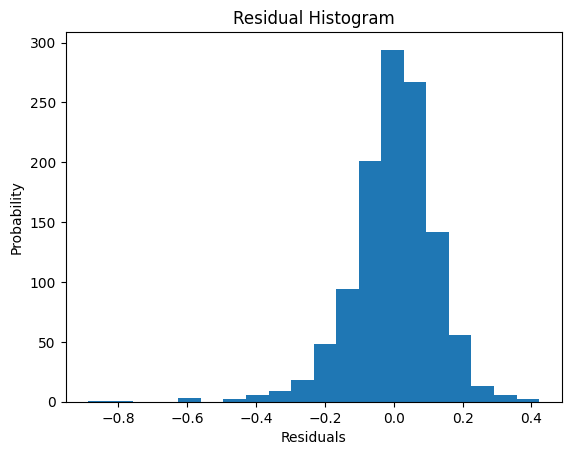

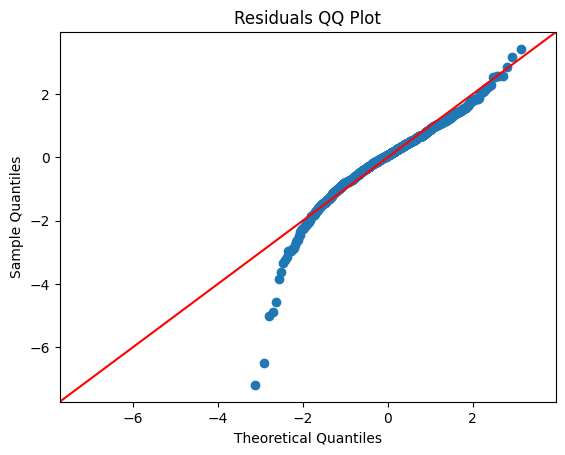

In [59]:
plt.hist(residuals, bins=20)
plt.title('Residual Histogram')
plt.xlabel('Residuals')
plt.ylabel('Probability')

sm.qqplot(residuals, line='45', fit=True)
plt.title('Residuals QQ Plot')
plt.show()

A histogram of the residuals was plotted to visually check for a roughly normal (bell-shaped) distribution, and a Q-Q plot (with `fit=True` to standardize the residuals) was used to compare the residual quantiles against a theoretical normal distribution. Points falling along the 45° reference line indicate normality; deviations at the tails suggest skew or heavy-tailedness.

**Finding:** residuals exhibited noticeable left skewness (skew ≈ -1.11) and heavy tails (kurtosis ≈ 8.31). Both the Omnibus and Jarque-Bera tests rejected the null hypothesis of normally distributed residuals at approximately p = 0.000. The normality assumption is technically violated.

**Mitigating factor:** the sample size is relatively large (n = 1163), and by the Central Limit Theorem, the sampling distribution of the coefficient estimates can still be approximately normal under suitable conditions. The non-normality of residuals is therefore less concerning for large-sample inference, though it is still acknowledged as a limitation.

### 5e. Multicollinearity (Condition Number, VIF)

Multicollinearity was assessed using the condition number reported in the OLS summary.

**Finding:** the condition number was approximately 7.53, well below the commonly used threshold of around 30 for serious multicollinearity concerns. This suggests the predictors do not exhibit problematic linear dependence — multicollinearity does not appear to be a major issue in the model.

### 5f. Influential Observations (Cook's Distance)

Although not one of the core linear regression assumptions, influential observations were examined as an additional diagnostic using Cook's Distance.

In [60]:
influence = OLSInfluence(ols_model2)
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(y_train_fs)
n_influential = sum(cooks_d > threshold)
print(f"Influential points (Cook's D > {threshold:.5f}): {n_influential}")

Influential points (Cook's D > 0.00344): 77


Cook's Distance was computed for each observation to identify points with disproportionate impact on the fitted model, using the common threshold of 4/n.

**Finding:** using threshold 4/n (n=1163), 77 observations (≈6.6%) were flagged as potentially influential.

**Decision:** these observations were not removed, as they appear to represent legitimate atypical properties (e.g. unusually large or high-value homes) rather than data-entry errors. Removing valid observations solely for exerting greater influence could distort the underlying data distribution and bias the model toward typical cases only.

### Summary: Linear Regression Assumption Checks

Overall, the model satisfies the assumptions of **linearity, independence of errors, and low multicollinearity** reasonably well. However, **homoscedasticity and normality of residuals are technically violated**. The violation of normality is less concerning given the relatively large sample size of 1163 observations, while the heteroscedasticity issue can be addressed for inference by using **heteroscedasticity-robust standard errors (HC3)**.

Therefore, the model remains useful, but statistical inference should rely on robust standard errors rather than the conventional OLS standard errors and p-values.

## 6. Final Model Selection

### 6a. OLS vs Ridge vs Lasso vs ElasticNet Comparison

Ridge and ElasticNet regularization strengths are tuned via cross-validation (`RidgeCV`, `ElasticNetCV`), then all four model types — OLS, Lasso, Ridge, ElasticNet — are fit on the final 21-feature set and compared on test R², test Adjusted R², and 5-fold cross-validated R² (mean and std), to determine which regression approach generalizes best on this data.

In [61]:
from sklearn.linear_model import LinearRegression, Lasso, LassoCV,Ridge, RidgeCV,ElasticNet, ElasticNetCV
from sklearn.model_selection import cross_val_score
ridge_cv=RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100, 1000],
    cv=5)
ridge_cv.fit(x_train_final2, y_train_fs)
best_alpha_ridge = ridge_cv.alpha_

ElasticNet_cv=ElasticNetCV(cv=5,random_state=42,max_iter=5000)
ElasticNet_cv.fit(x_train_final2, y_train_fs)
best_alpha_elastic = ElasticNet_cv.alpha_

models={
    'OLS': LinearRegression(),
    'Lasso': Lasso(alpha=0.005, max_iter=5000),
    'Ridge': Ridge(alpha=best_alpha_ridge, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=best_alpha_elastic, max_iter=5000)
}
results = []
for name, model in models.items():
    model.fit(x_train_final2, y_train_fs)
    y_pred = model.predict(x_test_final2)
    r2 = r2_score(y_test_fs, y_pred)
    adj_r2 = 1 - (1 - r2) * (len(y_test_fs) - 1) / (len(y_test_fs) - x_test_final2.shape[1] - 1)
    print(f"{name} Model: R2 = {r2:.4f}, Adjusted R2 = {adj_r2:.4f}")
    print()
    

    cv_scores = cross_val_score(model, x_train_final2, y_train_fs, cv=5, scoring='r2')
    print(f"{name} Model: Cross-validated R2 scores: {cv_scores}")
    print()
    results.append({
        'Model': name, 
        'Test R2': r2, 
        'Test Adj R2': adj_r2,
        'CV R2 (mean)': cv_scores.mean(),
        'CV R2 (std)': cv_scores.std()
    })
    
results_df = pd.DataFrame(results)
print(results_df)


OLS Model: R2 = 0.8698, Adjusted R2 = 0.8597

OLS Model: Cross-validated R2 scores: [0.90431743 0.91233619 0.89065944 0.86520653 0.88209117]

Lasso Model: R2 = 0.8708, Adjusted R2 = 0.8607

Lasso Model: Cross-validated R2 scores: [0.9007482  0.90741281 0.8900818  0.85998508 0.87658081]

Ridge Model: R2 = 0.8702, Adjusted R2 = 0.8601

Ridge Model: Cross-validated R2 scores: [0.90426195 0.91221864 0.89108276 0.86544874 0.88174994]

ElasticNet Model: R2 = 0.8701, Adjusted R2 = 0.8599

ElasticNet Model: Cross-validated R2 scores: [0.90429193 0.91226506 0.89085261 0.86513539 0.88200362]

        Model   Test R2  Test Adj R2  CV R2 (mean)  CV R2 (std)
0         OLS  0.869822     0.859660      0.890922     0.016597
1       Lasso  0.870793     0.860706      0.886962     0.017050
2       Ridge  0.870220     0.860089      0.890952     0.016520
3  ElasticNet  0.870069     0.859926      0.890910     0.016606


### 6a. OLS vs Ridge vs Lasso vs ElasticNet Comparison — Results

Four models were compared on the final 22-feature set: plain Linear 
Regression (OLS), Ridge, Lasso, and ElasticNet — each evaluated via a 
single test split (R², Adjusted R²) and 5-fold cross-validation for 
robustness.

| Model | Test R² | Test Adj R² | CV R² (mean) | CV R² (std) |
|---|---|---|---|---|
| OLS | 0.8698 | 0.8597 | 0.8909 | 0.0166 |
| Lasso | 0.8708 | 0.8607 | 0.8870 | 0.0171 |
| **Ridge** | 0.8702 | 0.8601 | **0.8910** | 0.0165 |
| ElasticNet | 0.8701 | 0.8599 | 0.8909 | 0.0166 |

**Finding:** all four models perform nearly identically — expected, 
since the 22-feature set was already carefully refined through 
Filter→Wrapper→Embedded selection, leaving little multicollinearity or 
redundancy for regularization to meaningfully act on (consistent with 
the low Condition Number of 7.53 found during assumption checking).

**Decision:** Ridge Regression selected as the final model. It achieves 
the best cross-validated R² (0.8910, effectively tied with OLS) while 
providing regularization as a safeguard against any residual 
multicollinearity, at no cost to performance.

### 6b. Final Model Decision

**Final model: Ridge Regression, alpha selected via `RidgeCV`, fit on the final 21-feature set** (22 features surviving Lasso at alpha=0.005, minus `HalfBath` after it was dropped for statistical insignificance in the OLS diagnostics stage).

This choice reflects the full pipeline built through the notebook, not just the last comparison table in isolation:

- **Feature selection did the heavy lifting.** Filter methods (duplicate check, correlation pruning, `f_regression`) cut 206 features down to 133; Wrapper (SFS) cut that to 50; Embedded (Lasso) cut that to 22. By the time regularization comparison happened in Section 6, the feature set was already lean and largely non-redundant — which is exactly why all four models scored within ~0.002 of each other. The heavy work of avoiding overfitting had already been done upstream, not by the final model choice itself.

- **Ridge over Lasso for the final model, despite Lasso being the tool used for feature selection.** Lasso's role in Section 4 was to shrink the feature set — a job it already finished. Using Lasso again as the final estimator would apply a second, redundant round of coefficient shrinkage, and there's a real risk it could zero out features that Lasso's own earlier run (at a different alpha) had already validated as informative — undermining the selection work done in 4g. Ridge instead shrinks coefficients smoothly without dropping features, which is the more appropriate role for a final model built on an already-selected feature set: stabilize the coefficients, don't re-select.

- **Ridge over plain OLS.** With a condition number of 7.53, multicollinearity isn't a serious concern here — but Ridge's cross-validated R² (0.8910) still edged out OLS (0.8909) at effectively zero cost, and Ridge carries structural insurance against the heteroscedasticity and influential-observations issues flagged in Section 5. Given the diagnostics showed real (if modest) violations of OLS's ideal conditions, a small, free amount of regularization is a reasonable hedge rather than an unnecessary complication.

- **Ridge over ElasticNet.** ElasticNet is a blend of Ridge and Lasso penalties, useful when you're uncertain whether shrinkage or elimination is more appropriate. Since feature elimination was already handled explicitly and deliberately in Section 4, there's no remaining ambiguity for ElasticNet's L1 component to resolve — it performed identically to Ridge here because it's functionally behaving like Ridge on this feature set. Choosing Ridge directly is simpler and equally effective without introducing an extra hyperparameter (`l1_ratio`) to justify.

**In short:** the final model is Ridge Regression not because it dramatically outperformed the alternatives — it didn't — but because it is the correct-shaped tool for the stage this notebook had reached: coefficient stabilization on an already-selected, already-validated feature set, with a small margin of protection against the diagnostic issues identified in Section 5.

---

This notebook took the Ames Housing dataset from 206 raw preprocessed features down to a final 21-feature Ridge Regression model, moving deliberately through Filter, Wrapper, and Embedded feature selection before validating the result against the standard linear regression assumptions. Every reduction step — duplicates, correlation pruning, `f_regression`, Sequential Forward Selection, Lasso — was checked against actual performance rather than applied blindly, and the diagnostic failures that did surface (heteroscedasticity, non-normal residuals) were investigated and addressed rather than ignored. The final model trades a small amount of raw R² for a leaner, more interpretable, and more defensible feature set — a deliberate choice throughout this notebook, not a limitation of it.